# 7. Case studies where the shallow centre misses deep topography

Candidates begin planetary dominated at the shallowest level but become topographic dominated at depth. Ranking is only a screening device; every track must be visually inspected for boundary effects, coverage and physical coherence.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / "seacofs_tilt_tools.py").exists()), None)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError("Run inside seacofs_eddy_tilt_analysis or one of its subfolders")
if str(ANALYSIS_ROOT) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_ROOT))
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

import seacofs_tilt_tools as tilt
import depth_pv_tools as dpt

sns.set_theme(style="whitegrid", context="notebook")
DOMINANCE_FACTOR = 2.0
TARGET_DEPTHS_M = (0, 200, 500, 700, 1000)
MIN_TILT_KM = 5.0
FIGSIZE = (8,4)

depth_df = tilt.add_pv_gradient_terms(source="depth")
snapshot_df = tilt.add_pv_gradient_terms(source="depth_snapshot")
dpt.validate_depth_tables(depth_df, snapshot_df)
DEPTHS = dpt.nearest_cached_depths(depth_df, TARGET_DEPTHS_M)
comparison = dpt.add_surface_differences(depth_df, DOMINANCE_FACTOR)
matched = dpt.matched_depth_rows(comparison, DEPTHS)
palette = {"AE": "#c44e52", "CE": "#4c72b0"}
depth_cmap = plt.get_cmap("viridis")
depth_colours = dict(zip(DEPTHS, depth_cmap(np.linspace(.08, .92, len(DEPTHS)))))
depth_labels = {z: f"{z:g} m" for z in DEPTHS}

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)


In [6]:
FIGSIZE = (8,4)

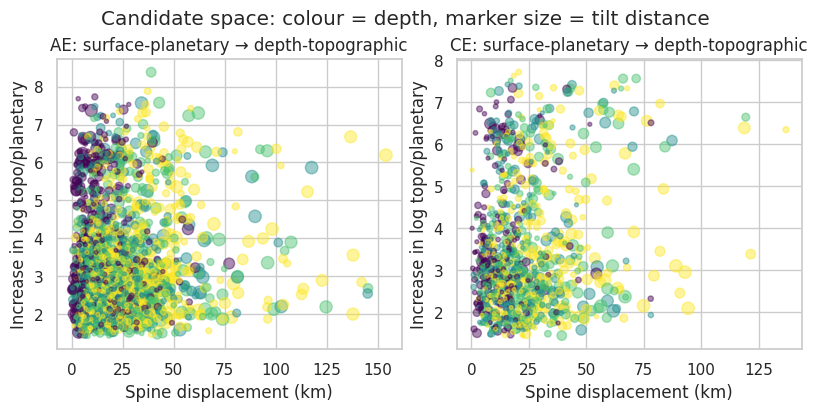

In [7]:
candidates = dpt.rank_mismatch_cases(matched[matched.Depth.isin(DEPTHS[1:])], MIN_TILT_KM)
top_ids = (candidates.groupby("Cyc", group_keys=False).head(3)["Eddy"].unique())

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE, constrained_layout=True)
for ax, cyc in zip(axes, ["AE","CE"]):
    part = candidates[candidates.Cyc.eq(cyc)]
    ax.scatter(part.spine_displacement_km, part.delta_topo_plan_ratio,
               c=part.Depth, cmap="viridis", s=np.clip(part.TiltDis, 8, 80), alpha=.45)
    ax.set(title=f"{cyc}: surface-planetary → depth-topographic", xlabel="Spine displacement (km)", ylabel="Increase in log topo/planetary")
fig.suptitle("Candidate space: colour = depth, marker size = tilt distance")
plt.show()

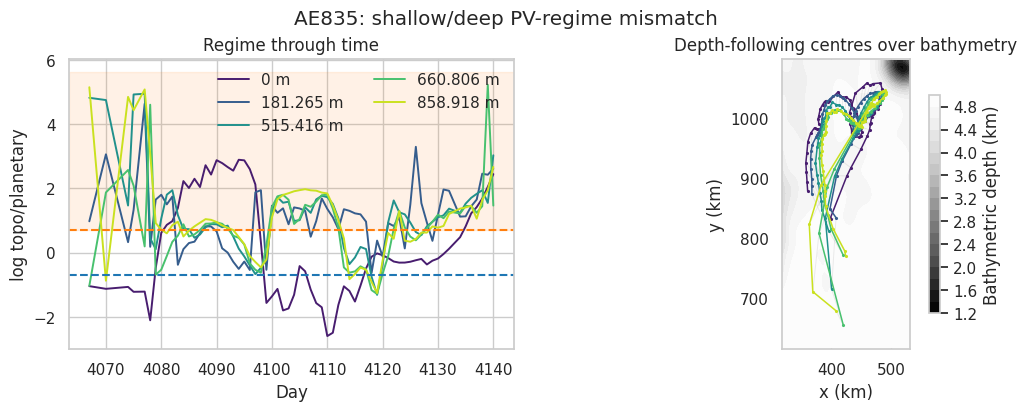

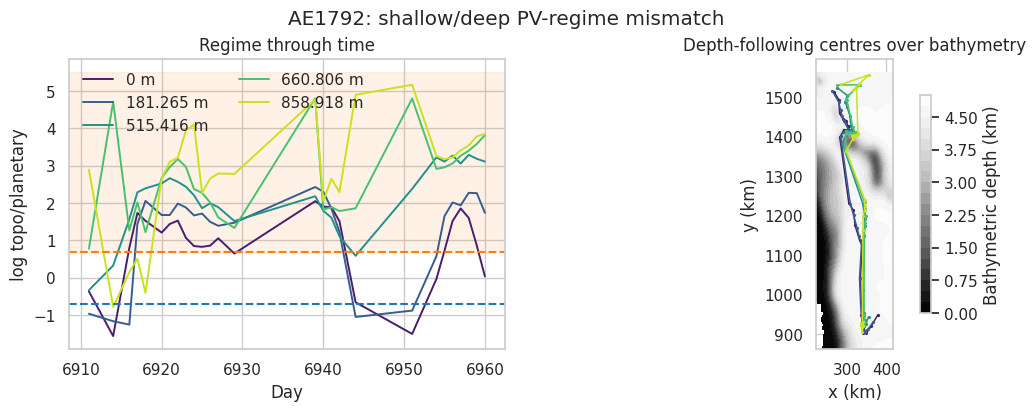

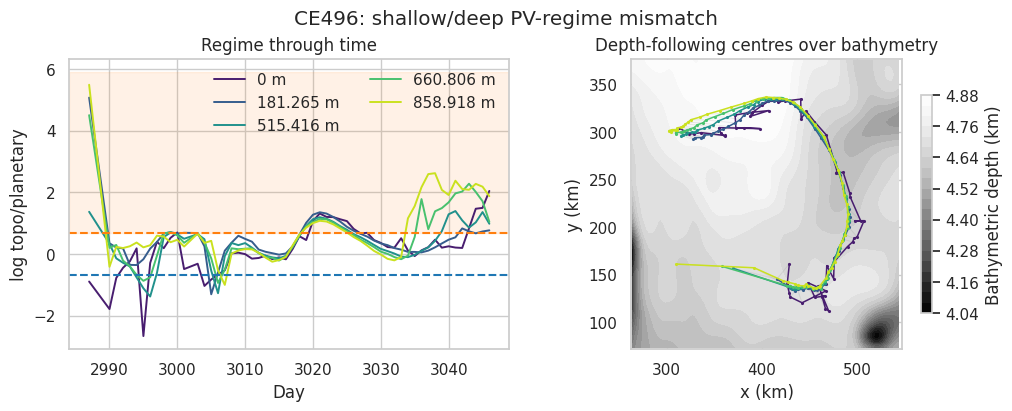

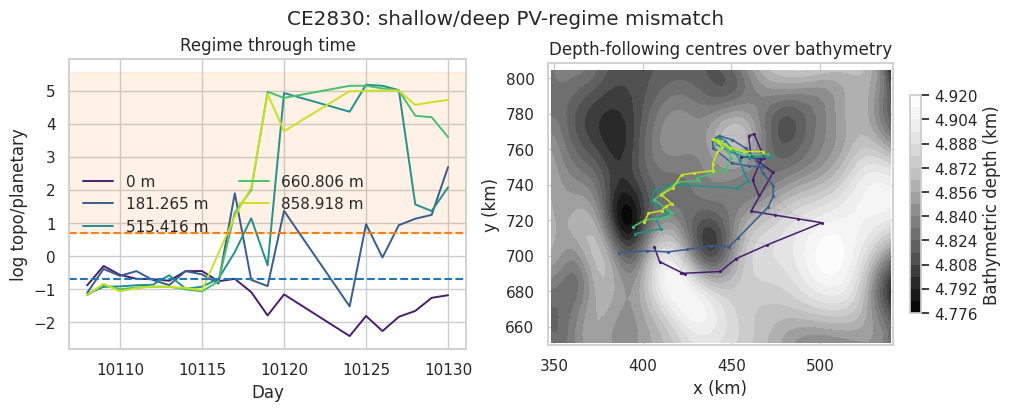

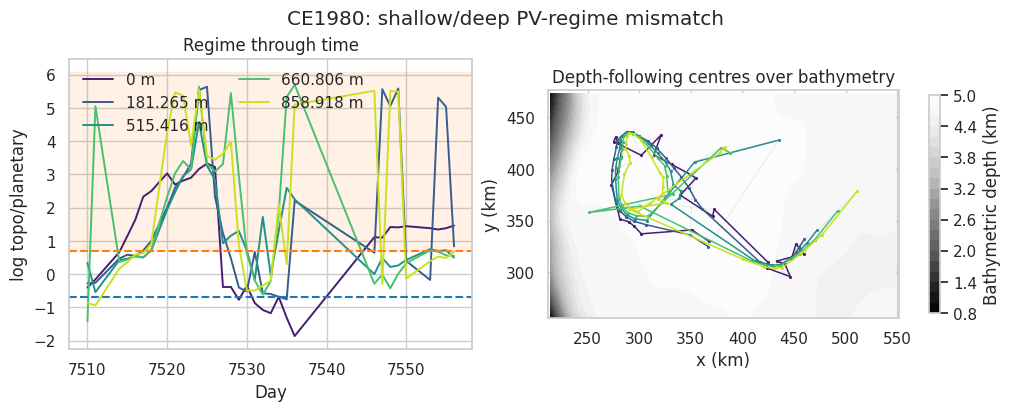

In [9]:
def plot_mismatch_eddy(eddy):
    track = matched[matched.Eddy.eq(eddy)].sort_values(["Day","Depth"]).copy()
    if track.empty:
        return
    cyc = track.Cyc.iloc[0]
    fig = plt.figure(figsize=(10,4), constrained_layout=True)
    gs = fig.add_gridspec(1,2, width_ratios=[1.15,1])
    ax = fig.add_subplot(gs[0]); ax2 = fig.add_subplot(gs[1])
    for z, part in track.groupby("Depth"):
        ax.plot(part.Day, part.topo_plan_ratio, color=depth_colours[z], lw=1.4, label=depth_labels[z])
    threshold = np.log(DOMINANCE_FACTOR)
    ax.axhspan(threshold, ax.get_ylim()[1], color="tab:orange", alpha=.10)
    ax.axhline(threshold, color="tab:orange", ls="--"); ax.axhline(-threshold, color="tab:blue", ls="--")
    ax.set(xlabel="Day", ylabel="log topo/planetary", title="Regime through time"); ax.legend(frameon=False, ncol=2)

    xmin, xmax = track.xc.min()-40, track.xc.max()+40
    ymin, ymax = track.yc.min()-40, track.yc.max()+40
    inside = ((grid.X_grid>=xmin)&(grid.X_grid<=xmax)&(grid.Y_grid>=ymin)&(grid.Y_grid<=ymax))
    bathy = np.where((grid.mask_rho==1)&inside, grid.h/1000, np.nan)
    cf = ax2.contourf(grid.X_grid, grid.Y_grid, bathy, levels=20, cmap="Greys_r")
    for day, spine in track.groupby("Day"):
        spine = spine.sort_values("Depth")
        ax2.plot(spine.xc, spine.yc, color="0.4", alpha=.12, lw=.7)
    for z, part in track.groupby("Depth"):
        ax2.plot(part.xc, part.yc, ".-", color=depth_colours[z], ms=2.5, lw=1.1)
    fig.colorbar(cf, ax=ax2, label="Bathymetric depth (km)", shrink=.75)
    ax2.set(xlabel="x (km)", ylabel="y (km)", xlim=(xmin, xmax), ylim=(ymin, ymax),
            title="Depth-following centres over bathymetry", aspect="equal")
    fig.suptitle(f"{cyc}{eddy}: shallow/deep PV-regime mismatch")
    plt.show()

for eddy in top_ids:
    plot_mismatch_eddy(eddy)

## Visual audit

Prefer cases with sustained rather than single-day switching, continuous depth coverage, coherent tracks, and a visibly plausible bathymetric feature beneath the displaced deep centre. These examples should illustrate—not establish—the population result.